# HVAC Demand analysis and prediction

## 2.2 Filtering Time series analysis

In [17]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# ARIMA
from pmdarima.arima import auto_arima

# Filter
from scipy.signal import savgol_filter
import multiprocessing

np.random.seed(42)


In [18]:
df = pd.read_csv("./data/Load_data_01.csv")
df["Time"] = pd.to_datetime(df["Time"])
df.set_index("Time", inplace=True)


In [19]:
# Parameters for Savitzky-Golay filter
window_size = 7  # Must be odd number!
poly_order = 3  # Polynomial order
df["Savegol"] = savgol_filter(df["electricity_demand_values"], window_size, poly_order, mode="nearest")


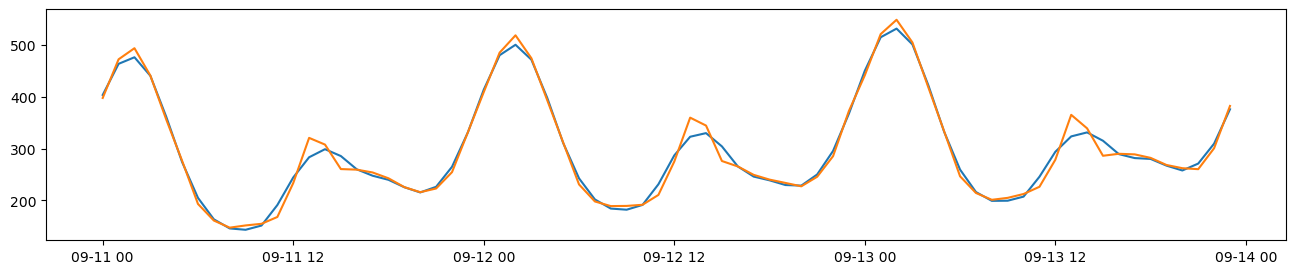

In [20]:
_, ax = plt.subplots(figsize=(16, 3))

ax.plot(df.query("'2018-09-11 ' <= Time < '2018-09-14'")["Savegol"])
ax.plot(df.query("'2018-09-11 ' <= Time < '2018-09-14'")["electricity_demand_values"])
plt.show()


In [21]:
# _, ax = plt.subplots(figsize=(16, 3))

# ax.plot(df.query("'2017-06-1 ' <= Time < '2017-06-10'")["Savegol"])
# ax.plot(df.query("'2017-06-1 ' <= Time < '2017-06-10'")["electricity_demand_values"])
# plt.show()


In [22]:
def rolling_days(start_date, window_size, pred_days):
    start_date = pd.to_datetime(start_date)
    for i in range(pred_days):
        end_date = start_date + pd.DateOffset(days=window_size - 1, hours=23)
        test_date = end_date + pd.DateOffset(hours=24)
        yield start_date, end_date, test_date
        start_date += pd.DateOffset(days=1)
        


In [23]:
def rolling_ARIMA(df, start_date, window_size, prediction_days):
    rmse_list = []
    r2_list = []
    for start_date, end_date, test_date in rolling_days(
        start_date, window_size, prediction_days
    ):
        train = df.query(f"'{start_date}' <= Time < '{end_date}'")["Savegol"]
        test = df.query(f"'{end_date}' <= Time < '{test_date}'")[
            "electricity_demand_values"
        ]
        model = auto_arima(
            train,
            seasonal=True,
            trace=True,
            m=24,
            error_action="ignore",
            suppress_warnings=True,
            njobs=multiprocessing.cpu_count(),
        )
        forecast = model.predict(n_periods=len(test))
        rmse = np.sqrt(mean_squared_error(test, forecast))
        r2 = r2_score(test, forecast)
        rmse_list.append(rmse)
        r2_list.append(r2)
        end_date_start = test_date + pd.DateOffset(hours=-23)
        print(f"Predition window: {end_date_start} to {test_date}")
        print(f"RMSE: {rmse}")
        print(f"R2 Score: {r2}")
    return rmse_list, r2_list


In [24]:
def rolling_ARIMA_df(df, start_date, window_size, prediction_days):
    result_data = []
    for start_date, end_date, test_date in rolling_days(
        start_date, window_size, prediction_days
    ):
        train = df.query(f"'{start_date}' <= Time < '{end_date}'")["Savegol"]
        test = df.query(f"'{end_date}' <= Time < '{test_date}'")[
            "electricity_demand_values"
        ]
        model = auto_arima(
            train,
            seasonal=True,
            trace=False,
            m=24,
            error_action="ignore",
            suppress_warnings=True,
            njobs=multiprocessing.cpu_count(),
        )

        forecast = model.predict(n_periods=len(test))
        rmse = np.sqrt(mean_squared_error(test, forecast))
        r2 = r2_score(test, forecast)
        end_date_start = test_date + pd.DateOffset(hours=-23)
        result_data.append([test_date, rmse, r2])
        print(f"Predition window: {end_date_start} to {test_date}")
        print(f"RMSE: {rmse}")
        print(f"R2 Score: {r2}")

    result_df = pd.DataFrame(result_data, columns=["Date", "RMSE", "R2 Score"])

    return result_df


In [ ]:
result_df_720 = rolling_ARIMA_df(df, "2018-07-20", 7, 50)


In [ ]:
result_df_720


In [36]:
result_df = rolling_ARIMA_df(df, "2017-08-01", 7, 50)
    

Predition window: 2017-08-08 00:00:00 to 2017-08-08 23:00:00
RMSE: 139.69863219259264
R2 Score: 0.6601814859210706
Predition window: 2017-08-09 00:00:00 to 2017-08-09 23:00:00
RMSE: 323.80885244940464
R2 Score: 0.33976353896879796
Predition window: 2017-08-10 00:00:00 to 2017-08-10 23:00:00
RMSE: 229.28426675129523
R2 Score: 0.5463939990382565
Predition window: 2017-08-11 00:00:00 to 2017-08-11 23:00:00
RMSE: 136.40296818012828
R2 Score: 0.7043112176526614
Predition window: 2017-08-12 00:00:00 to 2017-08-12 23:00:00
RMSE: 273.2591216688708
R2 Score: -0.25108571966259174
Predition window: 2017-08-13 00:00:00 to 2017-08-13 23:00:00
RMSE: 156.75450838389165
R2 Score: -1.4994499548355589
Predition window: 2017-08-14 00:00:00 to 2017-08-14 23:00:00
RMSE: 88.69830948746859
R2 Score: 0.540956374032225
Predition window: 2017-08-15 00:00:00 to 2017-08-15 23:00:00
RMSE: 105.48643711706252
R2 Score: 0.7149575746586867
Predition window: 2017-08-16 00:00:00 to 2017-08-16 23:00:00
RMSE: 226.14311087

In [38]:
result_df


,Date,RMSE,R2 Score
0,2017-08-08 23:00:00,139.698632,0.660181
1,2017-08-09 23:00:00,323.808852,0.339764
2,2017-08-10 23:00:00,229.284267,0.546394
3,2017-08-11 23:00:00,136.402968,0.704311
4,2017-08-12 23:00:00,273.259122,-0.251086
5,2017-08-13 23:00:00,156.754508,-1.499450
6,2017-08-14 23:00:00,88.698309,0.540956
7,2017-08-15 23:00:00,105.486437,0.714958
8,2017-08-16 23:00:00,226.143111,0.479686
9,2017-08-17 23:00:00,204.492800,0.676695


In [49]:
result_df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,50,2017-09-02 11:00:00,2017-08-08 23:00:00,2017-08-21 05:00:00,2017-09-02 11:00:00,2017-09-14 17:00:00,2017-09-26 23:00:00,NaN
RMSE,50.0,83.543934,14.205058,27.226541,41.024355,119.858176,323.808852,79.309339
R2 Score,50.0,0.539148,-3.734968,0.562344,0.848488,0.9327,0.979726,0.878749


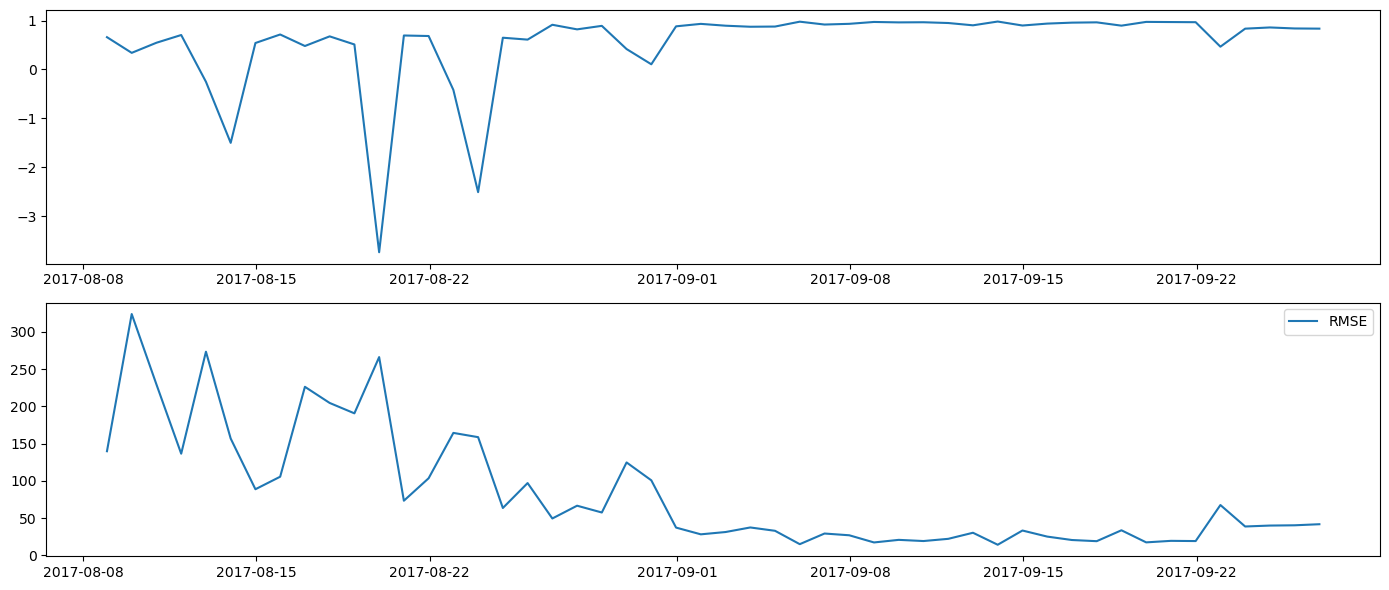

In [47]:
_, axes = plt.subplots(2,1,figsize=(14, 6))

axes[0].plot(result_df["Date"], result_df["R2 Score"],label="R2 Score")
axes[1].plot(result_df["Date"], result_df["RMSE"],label="RMSE")

plt.legend()
plt.tight_layout()
plt.show()


In [1]:
result_df


NameError: name 'result_df' is not defined